# Perceptron Trick for Binary Classification

In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                          n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

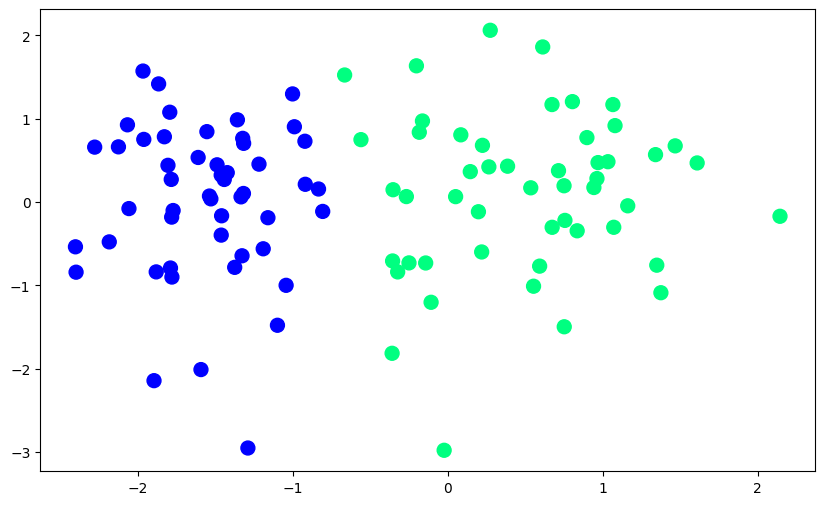

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter',s=100)

In [4]:
y[:5]

array([1, 1, 1, 0, 1])

## Perceptron trick logic and algorithm steps

- Logic: To bring a point from positive region of line to negative region, subtract its co-ordinates along with a 1 for the intercept from the co-efficients of the line and vice-versa.
- Use a learning rate to handle step size

- Algorithmic steps:
   1. Iterate for a certain number of epochs
   2. Select a random point in each iteration step
   3. Adjust the line based on point location
   4. Return intercept and coefficients

In [5]:
def step(z):
    return 1 if z>0 else 0

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def perceptron(X, y, activation):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, 100)
        y_hat = activation(np.dot(X[j], weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0], weights[1:]

### Step function activation

In [6]:
intercept, coef = perceptron(X, y, step)

In [7]:
intercept

np.float64(0.9)

In [8]:
coef

array([1.27889041, 0.23846949])

In [9]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [10]:
X_input = np.linspace(-3, 3, 100)
y_input = m*X_input + b

(-3.0, 2.0)

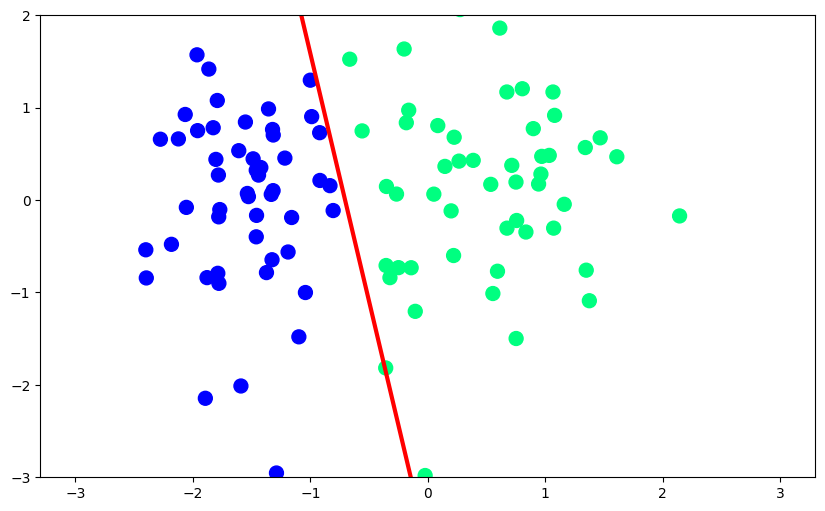

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter',s=100)
plt.ylim(-3, 2)

### Sigmoid activation

In [12]:
intercept, coef = perceptron(X, y, sigmoid)

In [13]:
intercept

np.float64(2.703319617076929)

In [14]:
coef

array([4.42273878, 0.13018187])

In [15]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [16]:
X_input = np.linspace(-3, 3, 100)
y_input = m*X_input + b

(-3.0, 2.0)

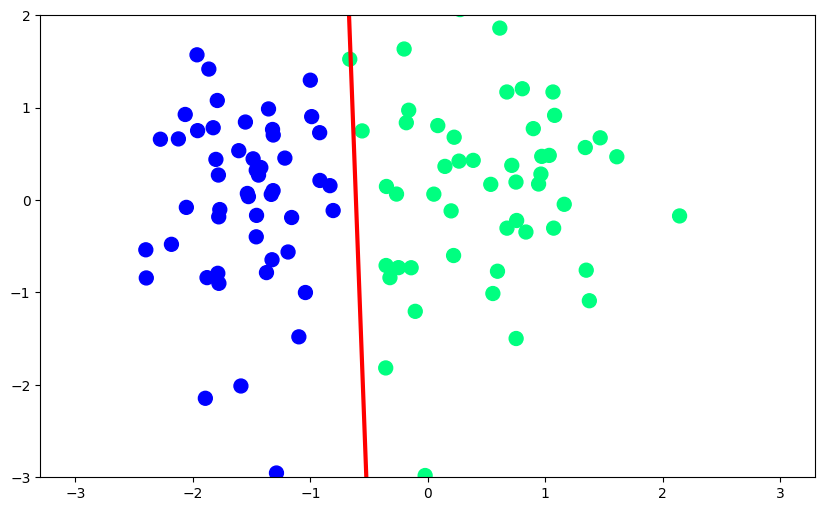

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter',s=100)
plt.ylim(-3, 2)